In [2]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")

print("Shape:", df.shape)
df.head()

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
print(df["location"].unique())

<StringArray>
[        'thane',   'navi-mumbai',        'nagpur',        'mumbai',
     'ahmedabad',     'bangalore',       'chennai',       'gurgaon',
     'hyderabad',        'indore',        'jaipur',       'kolkata',
       'lucknow',     'new-delhi',         'noida',          'pune',
          'agra',    'ahmadnagar',     'allahabad',    'aurangabad',
      'badlapur',       'belgaum',       'bhiwadi',      'bhiwandi',
        'bhopal',   'bhubaneswar',    'chandigarh',    'coimbatore',
      'dehradun',      'durgapur',     'ernakulam',     'faridabad',
     'ghaziabad',           'goa', 'greater-noida',        'guntur',
      'guwahati',       'gwalior',      'haridwar',      'jabalpur',
    'jamshedpur',       'jodhpur',        'kalyan',        'kanpur',
         'kochi',     'kozhikode',      'ludhiana',       'madurai',
     'mangalore',        'mohali',        'mysore',        'nashik',
       'navsari',       'nellore',      'palakkad',       'palghar',
     'panchkula',   

In [3]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [4]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
dtype: float64

In [5]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1)

Plot Area            100.0
Dimensions           100.0
Society               58.5
Super Area            57.4
Car Parking           55.1
overlooking           43.4
Carpet Area           43.0
facing                37.5
Ownership             34.9
Balcony               26.1
Price (in rupees)      9.4
Floor                  3.8
Description            1.6
Furnishing             1.5
Bathroom               0.4
Status                 0.3
Transaction            0.0
dtype: float64

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

Rows after price cleaning: (177847, 22)


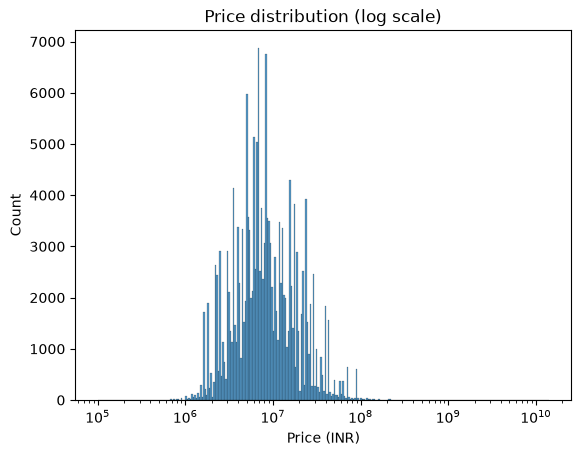

In [7]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

print("Rows after price cleaning:", df.shape)

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

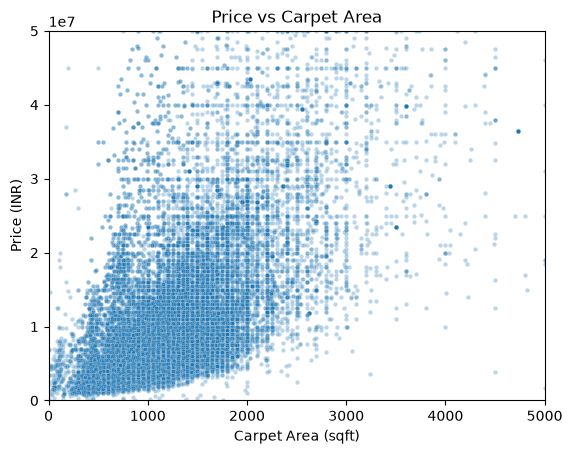

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float(x.replace("sqft", "").replace(",", "").strip())
        return num
    except ValueError:
        return None

df["carpet_area_sqft_temp"] = df["Carpet Area"].apply(parse_area)

sns.scatterplot(data=df, x="carpet_area_sqft_temp", y="price_clean", alpha=0.3, s=10)
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR)")
plt.xlim(0, 5000)  
plt.ylim(0, 5e7)
plt.show()

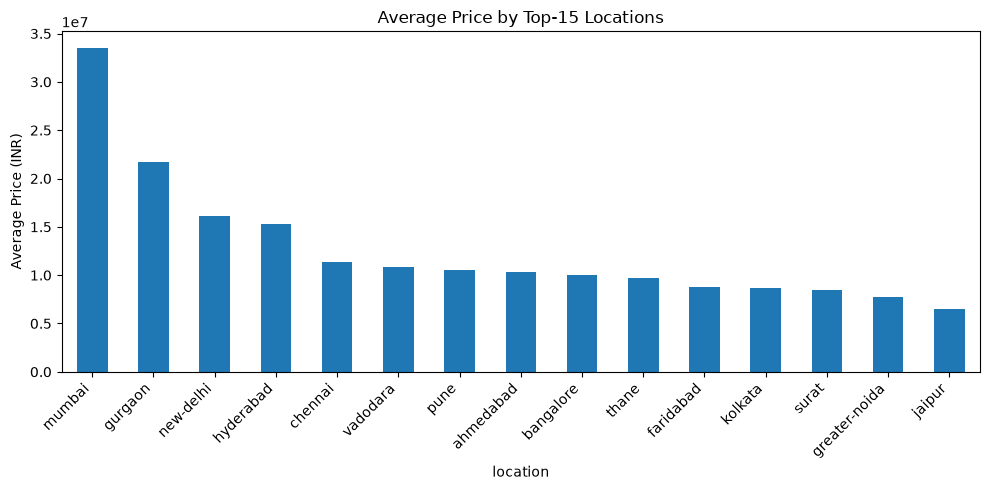

In [9]:
top_locations = df["location"].value_counts().head(15).index
avg_price_by_location = df[df["location"].isin(top_locations)].groupby("location")["price_clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_price_by_location.plot(kind="bar")
plt.title("Average Price by Top-15 Locations")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

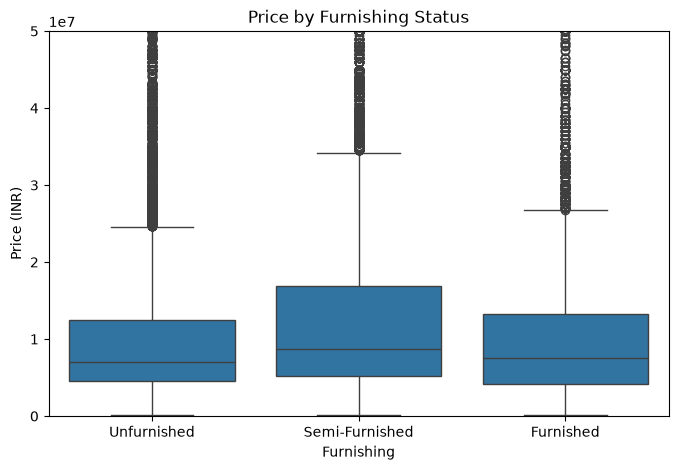

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Furnishing", y="price_clean")
plt.title("Price by Furnishing Status")
plt.ylabel("Price (INR)")
plt.ylim(0, 5e7)
plt.show()

In [11]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
print("After price cleaning:", df.shape)


def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqyrd" in x:
            return float(x.replace("sqyrd", "").strip()) * 9.0       
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764     
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)


df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])

print("Carpet area coverage after fallback:", df["carpet_area_sqft"].notna().mean().round(3))


def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first_part = x.split("out of")[0].strip()
    if first_part == "ground":
        return 0
    if first_part == "basement":
        return -1
    try:
        return int(first_part)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)


def parse_count(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if ">" in x:
        return 11.0
    try:
        return float(x)
    except ValueError:
        return None

df["bathroom"] = df["Bathroom"].apply(parse_count)
df["balcony"] = df["Balcony"].apply(parse_count)

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)


def parse_parking(x):
    if pd.isna(x):
        return 0.0
    x = str(x).strip()
    num = "".join(ch for ch in x if ch.isdigit())
    if num == "":
        return 0.0
    val = float(num)
    return min(val, 5.0)  

df["car_parking"] = df["Car Parking"].apply(parse_parking)


top_locations = df["location"].value_counts().head(50).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")


df = df.drop(columns=[
    "Index", "Title", "Description", "Dimensions", "Plot Area",
    "Amount(in rupees)", "Price (in rupees)",
    "Carpet Area", "Super Area", "Floor", "Bathroom", "Balcony", "Car Parking",
    "location", "Society"
], errors="ignore")


df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= lower) & (df["price_per_sqft"] <= upper)]
df = df.drop(columns=["price_per_sqft"])

print("Final shape after all cleaning:", df.shape)
df.head()

After price cleaning: (177847, 23)
Carpet area coverage after fallback: 0.999
Final shape after all cleaning: (174237, 15)


,Status,Transaction,Furnishing,facing,overlooking,Ownership,price_clean,carpet_area_sqft_temp,carpet_area_sqft,super_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped
0,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,4200000.0,500.0,500.0,NaN,10.0,1.0,2.0,0.0,thane
1,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Freehold,9800000.0,473.0,473.0,NaN,3.0,2.0,0.0,1.0,thane
2,Ready to Move,Resale,Unfurnished,East,Garden/Park,Freehold,14000000.0,779.0,779.0,NaN,10.0,2.0,0.0,1.0,thane
3,Ready to Move,Resale,Unfurnished,NaN,NaN,NaN,2500000.0,530.0,530.0,NaN,1.0,1.0,1.0,0.0,thane
4,Ready to Move,Resale,Unfurnished,West,"Garden/Park, Main Road",Co-operative Society,16000000.0,635.0,635.0,NaN,20.0,2.0,0.0,1.0,thane


In [12]:
# ==========================================
# Section 2.4: Build a Pipeline & Train
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony", "car_parking"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model 1: Linear Regression (baseline) ---
model_lr = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
model_lr.fit(X_train, y_train)
print("Linear Regression trained.")

# --- Model 2: Random Forest (نسخة مخففة تناسب أجهزة ضعيفة) ---
model_rf = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        n_jobs=-1,
        random_state=42
    ))
])
model_rf.fit(X_train, y_train)
print("Random Forest trained.")


# ==========================================
# Section 2.5: Evaluate
# ==========================================
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = {}
predictions = {}

for name, model in [("Linear Regression", model_lr), ("Random Forest", model_rf)]:
    pred = model.predict(X_test)
    predictions[name] = pred
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.3f}")

results_df = pd.DataFrame(results).T
results_df

Linear Regression trained.
Random Forest trained.
Linear Regression: MAE=4,119,119  RMSE=6,688,682  R2=0.683
Random Forest: MAE=1,126,441  RMSE=3,052,490  R2=0.934


,MAE,RMSE,R2
Linear Regression,4.119119e+06,6.688682e+06,0.682801
Random Forest,1.126441e+06,3.052490e+06,0.933937


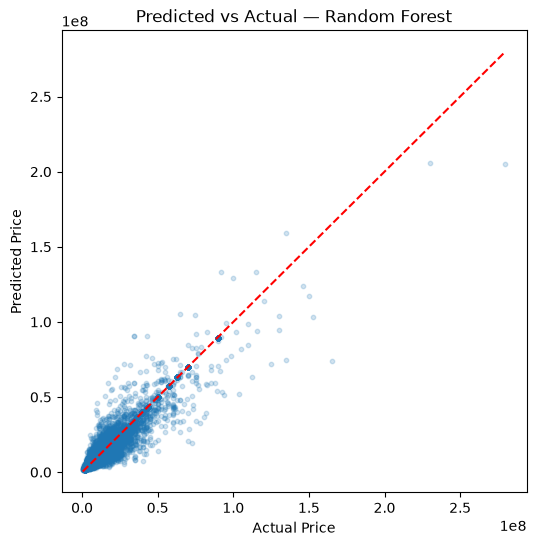

In [14]:
import matplotlib.pyplot as plt

best_model_name = "Random Forest"
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.2, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

In [ ]:

import joblib
import json

joblib.dump(model_rf, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

print("Export done: house_price.pkl + locations.json created in notebooks/ folder")

Reloaded prediction: [10018321.66015103]
Export done: house_price.pkl + locations.json created in notebooks/ folder
